<a href="https://colab.research.google.com/github/NamHyoeun11/jeonbot4-projects/blob/main/%EA%B3%BC%EC%A0%9C2_Distance_estimation(yolov5)_%EC%A7%81%EC%A0%91%EC%B0%8D%EC%9D%80%EC%82%AC%EC%A7%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 모델 다운로드
!git clone https://github.com/ultralytics/yolov5.git

Cloning into 'yolov5'...
remote: Enumerating objects: 17511, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 17511 (delta 5), reused 0 (delta 0), pack-reused 17494 (from 4)
Receiving objects: 100% (17511/17511), 16.65 MiB | 11.44 MiB/s, done.
Resolving deltas: 100% (11996/11996), done.


In [3]:
# yolov5 폴더로 이동하여 필요한 라이브러리들 설치
%cd yolov5
!pip install -r requirements.txt

/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
 

In [4]:
#사전 학습된 파라미터 다운로드
!wget https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt

--2025-07-11 05:41:01--  https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/264818686/381bd8a8-8910-4e9e-b0dd-2752951ef78c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-07-11T06%3A32%3A54Z&rscd=attachment%3B+filename%3Dyolov5s.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-07-11T05%3A32%3A48Z&ske=2025-07-11T06%3A32%3A54Z&sks=b&skv=2018-11-09&sig=Gn53g%2FrUudC%2F82nBtYlBrUm9jygKIDpT4Zilt548Nt0%3D&jwt=eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc1MjIxMjc2MSwibmJmIjoxNzUyMjEyNDYxLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmU

In [5]:
!pwd

/content/yolov5


In [6]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np
import io
import torch
from google.colab import files
uploaded = files.upload()
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving Picture7.jpg to Picture7.jpg


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-7-11 Python-3.11.13 torch-2.6.0+cu124 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


- 감지된 클래스: car
   거리 측정값: 10.1 m
- 감지된 클래스: car
   거리 측정값: 14.3 m
- 감지된 클래스: car
   거리 측정값: 16.2 m
- 감지된 클래스: car
   거리 측정값: 41.4 m
- 감지된 클래스: truck
- 감지된 클래스: car
   거리 측정값: 57.1 m
- 감지된 클래스: car
   거리 측정값: 42.9 m
- 감지된 클래스: car
   거리 측정값: 26.7 m


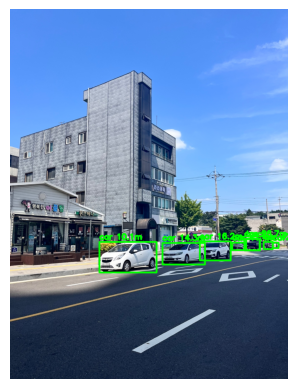

In [15]:
%matplotlib inline

import matplotlib.pyplot as plt

img = cv2.imread('Picture7.jpg')  # BGR
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # 모델용
img_bgr = img.copy()  # 시각화용 (BGR)

# 모델 로드
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')

# 추론
results = model(img_rgb)

# 거리 계산용 높이
known_heights = {
    "cup": 10,
    "mouse": 11,
    "scissors": 19,
    "person": 166,
    "car": 150
}
focal_length_px = 800

def estimate_distance(known_height_cm, focal_length_px, bbox_height_px):
    return (known_height_cm * focal_length_px) / bbox_height_px

# 결과 반복
for *box, conf, cls in results.xyxy[0]:
    label = model.names[int(cls)].lower()
    print("- 감지된 클래스:", label)

    x1, y1, x2, y2 = map(int, box)

    if label in known_heights:
        bbox_height = y2 - y1
        distance = estimate_distance(known_heights[label], focal_length_px, bbox_height)
        text = f"{label} {distance/100:.1f}m"
        print(f"   거리 측정값: {distance / 100:.1f} m")
    else:
        text = label

    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0, 255, 0), 6)
    cv2.putText(img_bgr, text, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 5)

# 출력용 RGB 변환
img_show = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 출력
#plt.figure(figsize=(10, 8))
plt.imshow(img_show)
plt.axis("off")
plt.show()

